In [1]:
!pip install pycaret

In [2]:
# Importar librerías
import pandas as pd
from pycaret.classification import * # Commented out the classification import
from pycaret.regression import * # Import the regression module

In [3]:
# Cargar el dataset procesado
df_raw = pd.read_excel('Copia de Data para prediccion.xlsx')
df_raw.head()  # Verificar la estructura del dataset
df = pd.read_excel('Copia de Data para prediccion.xlsx')

In [4]:
df.head()

,ID,Campaña,Zona,Granja,Sexo,Carga granja,Día 7,GAD 7-14,Día 14,GAD 14-21,...,Día 40,GAD 40-42,Día 42,Top ICA,Top IEP,Top Mortalidad,% total primera,% Segunda,% Cojo,% Descarte
0,20241SONOMAZAM,20241,POLLO SUR 3,SONOMAZA,M,101735,181,43.285714,484,69.857143,...,1833,0.0,0,1,2,2,0.967851,0.032149,0.000000,0.000000
1,20241SONOMAZAH,20241,POLLO SUR 3,SONOMAZA,H,103559,178,463.000000,877,1393.000000,...,2286,0.0,0,1,2,2,0.970654,0.020542,0.008804,0.000000
2,20241JUZAGUE 2M,20241,POLLO SUR 3,JUZAGUE 2,M,212755,177,476.000000,945,1510.000000,...,2863,28.5,2920,1,2,1,0.953105,0.036678,0.002560,0.007656
3,20241JUZAGUE 2H,20241,POLLO SUR 3,JUZAGUE 2,H,173942,174,468.000000,892,1347.000000,...,2359,20.5,2400,1,2,1,0.978987,0.009410,0.000000,0.011602
4,20241CHAMBARA 1M,20241,POLLO NORTE 2,CHAMBARA 1,M,210512,184,487.000000,952,1467.000000,...,1440,-88.0,1264,2,2,2,0.886679,0.065416,0.009058,0.038847


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               589 non-null    object 
 1   Campaña          589 non-null    int64  
 2   Zona             588 non-null    object 
 3   Granja           589 non-null    object 
 4   Sexo             589 non-null    object 
 5   Carga granja     589 non-null    int64  
 6   Día 7            589 non-null    int64  
 7   GAD 7-14         455 non-null    float64
 8   Día 14           589 non-null    int64  
 9   GAD 14-21        455 non-null    float64
 10  Día 21           589 non-null    int64  
 11  GAD 21-28        455 non-null    float64
 12  Día 28           589 non-null    int64  
 13  GAD 28-35        455 non-null    float64
 14  Día 35           589 non-null    int64  
 15  GAD 35-38        455 non-null    float64
 16  Día 38           589 non-null    int64  
 17  GAD 38-40       

In [6]:
df_raw.columns

Index(['ID', 'Campaña', 'Zona', 'Granja', 'Sexo', 'Carga granja', 'Día 7',
       'GAD 7-14', 'Día 14', 'GAD 14-21', 'Día 21', 'GAD 21-28', 'Día 28',
       'GAD 28-35', 'Día 35', 'GAD 35-38', 'Día 38', 'GAD 38-40', 'Día 40',
       'GAD 40-42', 'Día 42', 'Top ICA', 'Top IEP', 'Top Mortalidad',
       '% total primera', '% Segunda', '% Cojo', '% Descarte'],
      dtype='object')

In [7]:
df_raw.head()

,ID,Campaña,Zona,Granja,Sexo,Carga granja,Día 7,GAD 7-14,Día 14,GAD 14-21,...,Día 40,GAD 40-42,Día 42,Top ICA,Top IEP,Top Mortalidad,% total primera,% Segunda,% Cojo,% Descarte
0,20241SONOMAZAM,20241,POLLO SUR 3,SONOMAZA,M,101735,181,43.285714,484,69.857143,...,1833,0.0,0,1,2,2,0.967851,0.032149,0.000000,0.000000
1,20241SONOMAZAH,20241,POLLO SUR 3,SONOMAZA,H,103559,178,463.000000,877,1393.000000,...,2286,0.0,0,1,2,2,0.970654,0.020542,0.008804,0.000000
2,20241JUZAGUE 2M,20241,POLLO SUR 3,JUZAGUE 2,M,212755,177,476.000000,945,1510.000000,...,2863,28.5,2920,1,2,1,0.953105,0.036678,0.002560,0.007656
3,20241JUZAGUE 2H,20241,POLLO SUR 3,JUZAGUE 2,H,173942,174,468.000000,892,1347.000000,...,2359,20.5,2400,1,2,1,0.978987,0.009410,0.000000,0.011602
4,20241CHAMBARA 1M,20241,POLLO NORTE 2,CHAMBARA 1,M,210512,184,487.000000,952,1467.000000,...,1440,-88.0,1264,2,2,2,0.886679,0.065416,0.009058,0.038847


In [11]:
target1 = "% total primera"

variables1 = ["Sexo", "Carga granja", "Día 7", "Día 14", "Día 21", "Día 28", "Día 35", "Día 38", "Top ICA", "Top IEP", "Top Mortalidad"]

In [12]:
df = df_raw[variables1 + [target1]]

In [13]:
df.head()

,Sexo,Carga granja,Día 7,Día 14,Día 21,Día 28,Día 35,Día 38,Top ICA,Top IEP,Top Mortalidad,% total primera
0,M,101735,181,484,973,1597,2318,2623,1,2,2,0.967851
1,H,103559,178,877,1965,2286,1965,2052,1,2,2,0.970654
2,M,212755,177,945,2289,2863,2289,2689,1,2,1,0.953105
3,H,173942,174,892,1920,2359,1920,2237,1,2,1,0.978987
4,M,210512,184,952,2084,1440,2084,1743,2,2,2,0.886679


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sexo             589 non-null    object 
 1   Carga granja     589 non-null    int64  
 2   Día 7            589 non-null    int64  
 3   Día 14           589 non-null    int64  
 4   Día 21           589 non-null    int64  
 5   Día 28           589 non-null    int64  
 6   Día 35           589 non-null    int64  
 7   Día 38           589 non-null    int64  
 8   Top ICA          589 non-null    int64  
 9   Top IEP          589 non-null    int64  
 10  Top Mortalidad   589 non-null    int64  
 11  % total primera  589 non-null    float64
dtypes: float64(1), int64(10), object(1)
memory usage: 55.3+ KB


In [15]:
df['Sexo'] = df['Sexo'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Sexo             589 non-null    category
 1   Carga granja     589 non-null    int64   
 2   Día 7            589 non-null    int64   
 3   Día 14           589 non-null    int64   
 4   Día 21           589 non-null    int64   
 5   Día 28           589 non-null    int64   
 6   Día 35           589 non-null    int64   
 7   Día 38           589 non-null    int64   
 8   Top ICA          589 non-null    int64   
 9   Top IEP          589 non-null    int64   
 10  Top Mortalidad   589 non-null    int64   
 11  % total primera  589 non-null    float64 
dtypes: category(1), float64(1), int64(10)
memory usage: 51.4 KB


In [16]:
# Configurar el entorno de PyCaret
# Changed from setup (classification) to setup (regression)
reg = setup(df,
            target=target1,          # Columna objetivo
            session_id=123,            # Para reproducibilidad
            normalize=True,            # Normalización de datos
            feature_selection=False,    # Activar selección de características
            # n_features_to_select=6, # Removed as feature_selection is False
            remove_multicollinearity=True,  # Eliminar multicolinealidad
            multicollinearity_threshold=0.9, # Umbral de multicolinealidad
            transformation=True,        # Aplicar transformaciones
            train_size=0.7,             # Tamaño de la muestra de entrenamiento
            fold=10,                      # Validación cruzada
            remove_outliers=True

            #funcion de perdida
            #
            # ignore_features=[]
)

,Description,Value
0,Session id,123
1,Target,% total primera
2,Target type,Regression
3,Original data shape,"(589, 12)"
4,Transformed data shape,"(568, 11)"
5,Transformed train set shape,"(391, 11)"
6,Transformed test set shape,"(177, 11)"
7,Numeric features,10
8,Categorical features,1
9,Preprocess,True


In [18]:
df.head()

,Sexo,Carga granja,Día 7,Día 14,Día 21,Día 28,Día 35,Día 38,Top ICA,Top IEP,Top Mortalidad,% total primera
0,M,101735,181,484,973,1597,2318,2623,1,2,2,0.967851
1,H,103559,178,877,1965,2286,1965,2052,1,2,2,0.970654
2,M,212755,177,945,2289,2863,2289,2689,1,2,1,0.953105
3,H,173942,174,892,1920,2359,1920,2237,1,2,1,0.978987
4,M,210512,184,952,2084,1440,2084,1743,2,2,2,0.886679


In [20]:
# Remove the 'Sexo' column before calculating correlation
df_numeric = df.drop('Sexo', axis=1)
corr_matrix = df_numeric.corr()
print(corr_matrix)

                 Carga granja     Día 7    Día 14    Día 21    Día 28  \
Carga granja         1.000000  0.002168  0.014165 -0.019554  0.065338   
Día 7                0.002168  1.000000  0.228492  0.152418  0.057098   
Día 14               0.014165  0.228492  1.000000  0.960870  0.340482   
Día 21              -0.019554  0.152418  0.960870  1.000000  0.392051   
Día 28               0.065338  0.057098  0.340482  0.392051  1.000000   
Día 35              -0.035480  0.317791 -0.077740  0.030262  0.128466   
Día 38              -0.021501  0.134230  0.049565  0.144438  0.465071   
Top ICA              0.014687 -0.197505 -0.013876  0.014982 -0.171423   
Top IEP              0.086866 -0.066243  0.061124  0.074856  0.017912   
Top Mortalidad       0.008570 -0.072549  0.041372  0.057154 -0.037929   
% total primera     -0.068778  0.173959  0.147043  0.149804  0.204567   

                   Día 35    Día 38   Top ICA   Top IEP  Top Mortalidad  \
Carga granja    -0.035480 -0.021501  0.014687  0

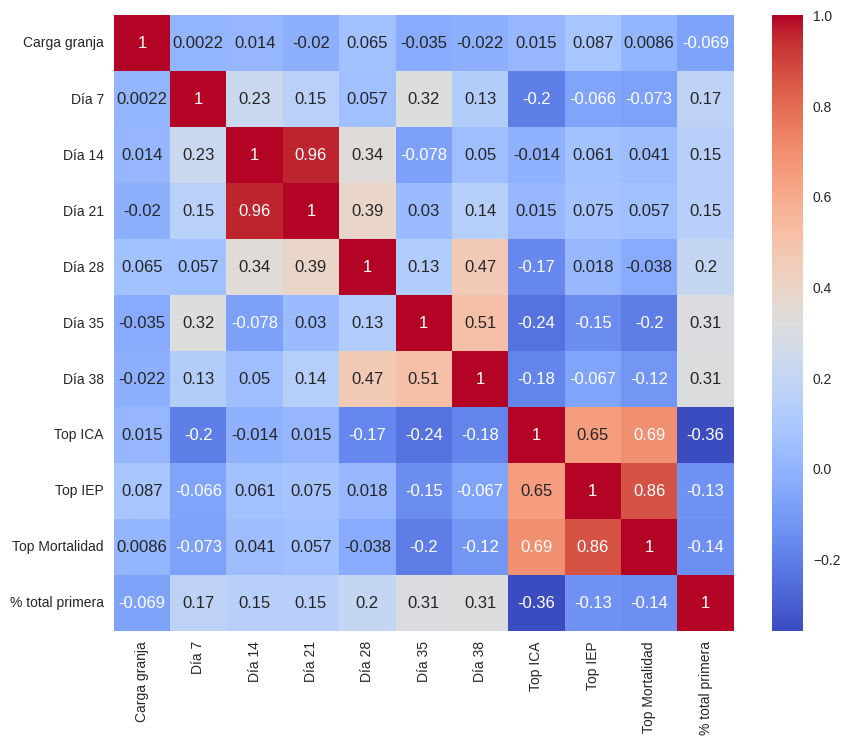

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [22]:
# Comparar modelos
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,0.0739,0.0216,0.1403,0.2760,0.0913,0.2431,0.2420
rf,Random Forest Regressor,0.0794,0.0200,0.1360,0.2639,0.0881,0.2191,0.4890
br,Bayesian Ridge,0.0845,0.0201,0.1369,0.2609,0.0884,0.2348,0.2250
lar,Least Angle Regression,0.0862,0.0201,0.1371,0.2512,0.0882,0.2347,0.2250
ridge,Ridge Regression,0.0858,0.0202,0.1373,0.2499,0.0885,0.2352,0.2240
lr,Linear Regression,0.0860,0.0202,0.1374,0.2483,0.0885,0.2353,0.8510
gbr,Gradient Boosting Regressor,0.0806,0.0204,0.1392,0.2101,0.0890,0.2232,0.3270
xgboost,Extreme Gradient Boosting,0.0768,0.0197,0.1366,0.1963,0.0883,0.2126,0.4680
lightgbm,Light Gradient Boosting Machine,0.0864,0.0218,0.1429,0.1525,0.0914,0.2361,0.8650
knn,K Neighbors Regressor,0.0849,0.0231,0.1477,0.0932,0.0944,0.2382,0.3280


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [23]:
model_select = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0610,0.0106,0.1032,0.3867,0.0627,0.0824
1,0.0970,0.0390,0.1975,-0.0502,0.1335,0.2045
2,0.1050,0.0334,0.1828,0.3046,0.1240,0.2004
3,0.0768,0.0124,0.1114,0.3635,0.0644,0.1051
4,0.0935,0.0251,0.1583,0.2824,0.1007,0.2070
5,0.0604,0.0089,0.0944,0.5023,0.0555,0.0837
6,0.1111,0.0333,0.1824,0.3136,0.1223,0.4631
7,0.0639,0.0096,0.0980,-0.4843,0.0545,0.0731
8,0.0490,0.0111,0.1053,0.5590,0.0767,0.6927


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [24]:
  # Afinar el mejor modelo
  # tuned_model = tune_model(best_model)
  #Cambiar priorizacion a Mape y Mae
tuned_model = tune_model(model_select, optimize="MAPE")

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0626,0.0084,0.0918,0.5141,0.0547,0.0859
1,0.0945,0.0381,0.1951,-0.0250,0.1325,0.1989
2,0.1037,0.0333,0.1823,0.3079,0.1238,0.2028
3,0.0745,0.0125,0.1116,0.3607,0.0652,0.1021
4,0.0944,0.0255,0.1597,0.2702,0.1015,0.2086
5,0.0688,0.0119,0.1093,0.3328,0.0643,0.0983
6,0.1073,0.0334,0.1829,0.3097,0.1231,0.4695
7,0.0606,0.0080,0.0896,-0.2404,0.0495,0.0702
8,0.0551,0.0123,0.1108,0.5120,0.0793,0.7163


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
tuned_model2 = tune_model(model_select, optimize="MAE")

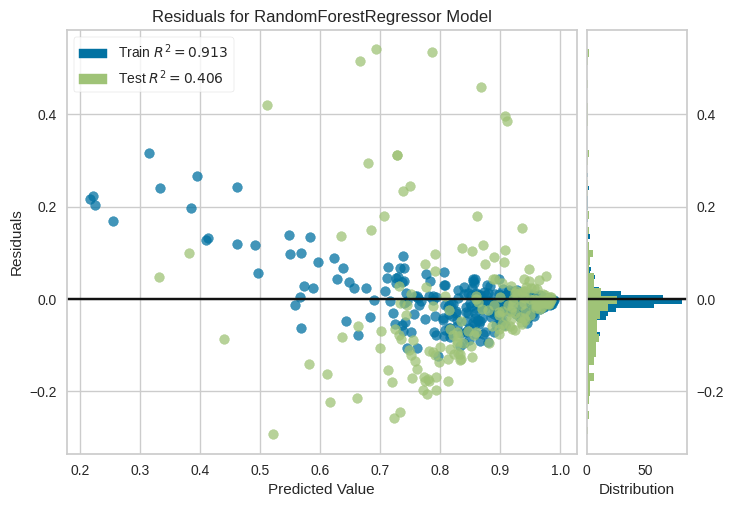

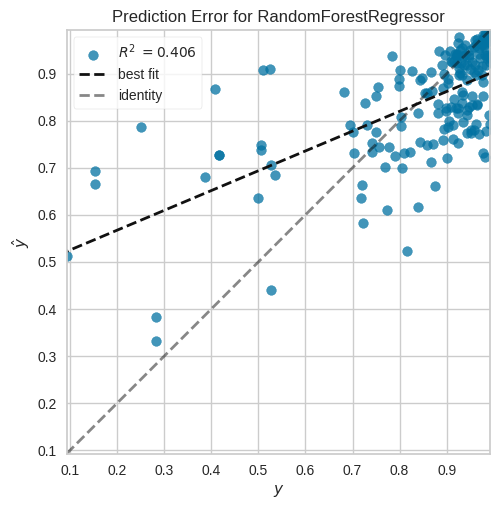

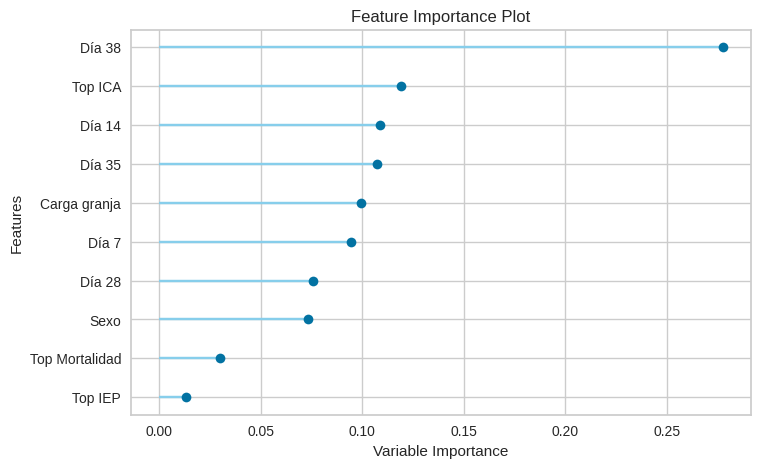

In [25]:
plot_model(tuned_model, plot='residuals')
plot_model(tuned_model, plot='error')
plot_model(tuned_model, plot='feature')


In [26]:
predictions = predict_model(tuned_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,0.0913,0.0191,0.1384,0.4058,0.0860,0.1878


In [27]:
predicted_values = predictions['prediction_label']
actual_values = get_config('y_test')

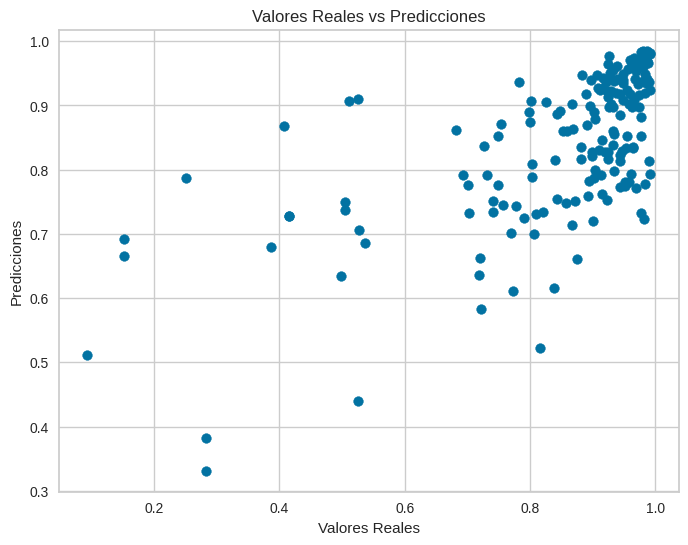

In [28]:
import matplotlib.pyplot as plt

# Crear el gráfico de dispersión
plt.figure(figsize=(8,6))
plt.scatter(actual_values, predicted_values)

# Añadir etiquetas y título
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Valores Reales vs Predicciones')

# Mostrar el gráfico
plt.show()

In [29]:
comparison_df = pd.DataFrame({'Actual': actual_values, 'Predicted': predictions['prediction_label']})
print(comparison_df)

       Actual  Predicted
512  0.741468   0.733582
54   0.919020   0.827986
511  0.912860   0.791337
192  0.984456   0.918805
415  0.925048   0.965064
..        ...        ...
49   0.251397   0.786787
345  0.720242   0.662504
487  0.897166   0.940057
22   0.801097   0.907606
157  0.907673   0.947116

[177 rows x 2 columns]


In [30]:
evaluate_model(tuned_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…